In [1]:
import numpy as np
from numpy import pi, arccos, cos, sin, tan, mean
import matplotlib.pyplot as plt
from cats.cdataframe import CDataFrame
import glob

Welcome to JupyROOT 6.28/10


In [2]:
# Gather sample files containing electron (e) and hole (h) tracks under 0V and 4V in HVeV NF-C detector

Vs = ['0V', '4V']
charges = ['h', 'e']

DMC_filenames = {V: {charge: sorted(glob.glob(f'/scratch/group/mitchcomp/CDMS/data/perry5334/MSC_NTLemission_samples/{charge}_{V}_new/' + 
                                               'stepcounter_5124????_0000??.root')) for charge in charges} for V in Vs}

In [3]:
# Use CATs to read the needed quantities from the mcHitCounter tree

parameters = (['EventNum', 'KE', 'KE3', 'Process', 'Charge', 'PName', 'TrkStep', 'Parent', 'Weight'] + 
              [label + sequence for sequence in ['1', '3'] for label in ['X', 'Y', 'Z', 'Xmom', 'Ymom', 'Zmom', 'Time', 'V']])

data = {V: {charge: None for charge in charges} for V in Vs}

for V in Vs:
    for charge in charges:
        mcHitCounter = CDataFrame('G4SimDir/mcHitCounter', DMC_filenames[V][charge])
        data[V][charge] = mcHitCounter.AsNumpy(parameters)

In [4]:
# Define function to concatenate the start of step (1) and end of step (3) quantities for plotting
def merge(X1, X3):
    return np.concatenate([[X1[i], X3[i]] for i in range(len(X1))])

In [5]:
# A charge in a semi-conductor will scatter while it propagates. Each scatter will result in a parent phonon which will then down-convert
# into two low-energy phonons and so on. Each scatter will result in a small phonon cascade. The next cell will plot the cascade of phonons
# which result from one charge-phonon scatter.

Text(0, 0.5, 'Z position [mm]')

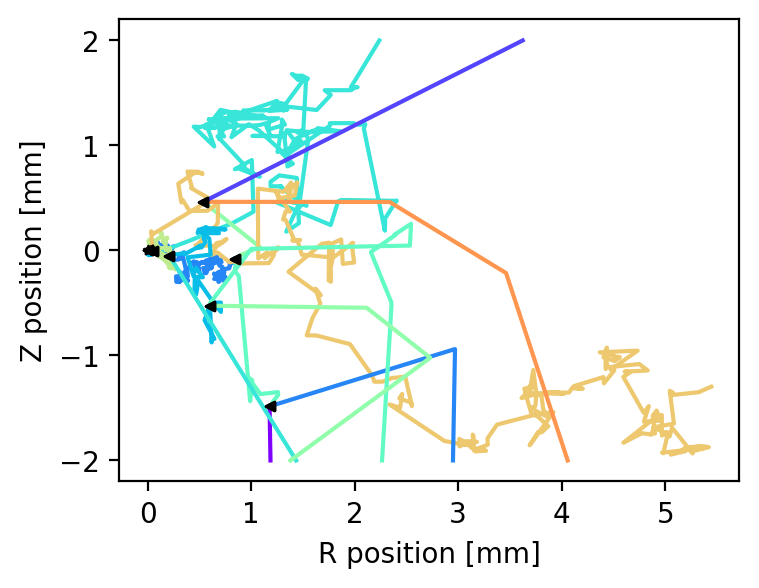

In [6]:
# Start with the simple case of a hole propagating under 0 V.

V = '0V'
charge = 'h'
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.rainbow(np.linspace(0,0.8,10)))

plt.figure(figsize = (4,3), dpi=200)

# Let's look at just the first event.
for event in np.unique(data[V][charge]['EventNum'])[:1]:
    
    # set up cuts for the event number, hole scatters, and phonons
    eventCut = data[V][charge]['EventNum'] == event
    hCut = (data[V][charge]['Charge'] == 1) & (data[V][charge]['Process'] == 'G4CMPLukeScattering')
    phCut = data[V][charge]['Charge'] == 0

    # Extract the positions for the start and stop of the each step taken in this event
    X1, Y1, Z1 = data[V][charge]['X1'], data[V][charge]['Y1'], data[V][charge]['Z1']
    X3, Y3, Z3 = data[V][charge]['X3'], data[V][charge]['Y3'], data[V][charge]['Z3']

    # Define 'Rs' and 'Zs' which are the start and stop positions of steps that were limited by the hole scattering
    Rs = np.sqrt(merge(X1[eventCut & hCut], X3[eventCut & hCut]) ** 2 + merge(Y1[eventCut & hCut], Y3[eventCut & hCut]) ** 2)
    Zs = merge(Z1[eventCut & hCut], Z3[eventCut & hCut])

    # Plot the first step the hole takes that results in a charge-phonon scatter (and a cascade of phonons)
    # (Plotting this is completely optional)
    plt.scatter([Rs[:1]*1e3], [Zs[:1]*1e3], color = 'black', marker = '*', zorder = 1000, s = 10)

    # We want to find a phonon track that starts at the same time the first scatter ends (Time1(phonon) == Time3(hole)).
    # Let's look at the time that the first hole scatter finishes.
    for time in data[V][charge]['Time3'][hCut & eventCut][:1]:
        
        # Find a step that starts at the same time the hole scatter step ends
        emissionCut = abs(data[V][charge]['Time1'] - time) < 1e-9
        
        # Find the TrkStep quantity of the phonon that is emitted from the charge-phonon scatter using the event cut, phonon cut, and time cut just defined
        TrkStep = data[V][charge]['TrkStep'][emissionCut & phCut & eventCut]
        
        # Define a cut to identify all the steps taken by the identified phonon. The phonon track's 'TrkStep' field operated on with // 100,000 will
        # always have the same value for all steps.
        # The cut below allows us to identify all of the steps that belong to one phonon.
        TrkCut = data[V][charge]['TrkStep'] // 100000 == TrkStep // 100000

        # Again, define 'Rs' and 'Zs' of this parent phonon. It has to obey the cuts we identified before
        # It has to belong to the first event
        # It has to have Charge == 0 (be a phonon)
        # and has to belong to the track that we identified as resulting from the first charge-phonon scatter.
        Rs = np.sqrt(merge(X1[eventCut & phCut & TrkCut], X3[eventCut & phCut & TrkCut]) ** 2 + merge(Y1[eventCut & phCut & TrkCut], Y3[eventCut & phCut & TrkCut]) ** 2)
        Zs = merge(Z1[eventCut & phCut & TrkCut], Z3[eventCut & phCut & TrkCut])
        
        # We plot the track of this first phonon.
        plt.plot(Rs*1e3, Zs*1e3, alpha = 0.5)

        # We expect that this first phonon might decay into two more phonons.
        # We check to see if any track starts (Time1) at the same time that this track ends (Time3)
        timeCut = abs(data[V][charge]['Time1'] - data[V][charge]['Time3'][eventCut & phCut & TrkCut][-1]) < 1e-9

        # If there are daughter phonons, we enter a while loop that handles plotting the rest of the cascade of phonons
        while any(timeCut):
            
            # We identify the track numbers of the phonons that result from this parent phonon.
            # We expect that there are two since a parent phonon will decay into two daughter phonons.
            decayTrks = data[V][charge]['TrkStep'][timeCut & phCut & eventCut] // 100000
            
            # We also set up a boolean array which we will use to determine if we stay in this while loop.
            timeCut = np.full(len(data[V][charge]['Time1']), False)
            
            #Let's loop through each of the tracks belonging to the daughter phonons and plot them.
            for Trk in decayTrks:
                
                # Define a Track cut as before to capture the whole track belonging to the daughter phonon
                TrkCut = data[V][charge]['TrkStep'] // 100000 == Trk
                
                # Extract 'Rs' and 'Zs' values for plotting
                Rs = np.sqrt(merge(X1[eventCut & phCut & TrkCut], X3[eventCut & phCut & TrkCut]) ** 2 + merge(Y1[eventCut & phCut & TrkCut], Y3[eventCut & phCut & TrkCut]) ** 2)
                Zs = merge(Z1[eventCut & phCut & TrkCut], Z3[eventCut & phCut & TrkCut])
                
                # We also save the time at which this track ends
                T3 = data[V][charge]['Time3'][eventCut & phCut & TrkCut][-1]
                
                # We update our boolean array to capture tracks which may start at the time that the daughter phonons may decay
                # This is used in the while loop to determine if there are more phonons in the cascade that need to be plotted.
                timeCut = timeCut | (abs(data[V][charge]['Time1'] - T3) < 1e-9)

                # This if statement is used to ignore phonons that result from quasiparticle recombination
                # in the QETs. This statement can be commented out or removed if that effect is important
                if abs(Zs[0] - 0.0019994) < 1e-5:
                    continue

                # Plot the track of each daughter phonon
                # Including a scatter point of each decay for visual clarity
                plt.scatter([Rs[0]*1e3], [Zs[0]*1e3], color = 'black', marker = '<', zorder = 1000, s = 10)
                plt.plot(Rs*1e3, Zs*1e3)

plt.xlabel(r'R position [mm]')
plt.ylabel(r'Z position [mm]')